<a href="https://colab.research.google.com/github/Shiva-Kumar-S-M/Placement-Training/blob/main/Project_(Ensemble).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier



from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [4]:
df=pd.read_csv('/content/customer_churn_dataset-testing-master.csv')


In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df['Gender']=np.where(df['Gender']=='Female',1,0)


In [6]:
X=df.drop(['Subscription Type','Churn','Contract Length'],axis=1)
y=df['Churn']

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
rf=RandomForestClassifier().fit(X_train,y_train)
rf_pred=rf.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,rf_pred))
print("Classification Report: \n",classification_report(y_test,rf_pred))

Accuracy Score:  0.9805048543689321
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      6793
           1       0.99      0.97      0.98      6082

    accuracy                           0.98     12875
   macro avg       0.98      0.98      0.98     12875
weighted avg       0.98      0.98      0.98     12875



In [8]:
xgb=XGBClassifier().fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,xgb_pred))
print("Classification Report: \n",classification_report(y_test,xgb_pred))

Accuracy Score:  0.9789514563106796
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      6793
           1       0.99      0.97      0.98      6082

    accuracy                           0.98     12875
   macro avg       0.98      0.98      0.98     12875
weighted avg       0.98      0.98      0.98     12875



In [9]:
lbg=LGBMClassifier().fit(X_train,y_train)
lbg_pred=lbg.predict(X_test)

print("Accuracy Score: ",accuracy_score(y_test,lbg_pred))
print("Classification Report: \n",classification_report(y_test,lbg_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 24411, number of negative: 27088
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005743 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 726
[LightGBM] [Info] Number of data points in the train set: 51499, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474009 -> initscore=-0.104057
[LightGBM] [Info] Start training from score -0.104057
Accuracy Score:  0.9817475728155339
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      6793
           1       0.99      0.97      0.98      6082

    accuracy                           0.98     12875
   macro avg       0.98      0.98      0.98     12875
weighted avg       0.98      0.98      0.98     12875



In [10]:
comparision=pd.DataFrame({
    'model':[
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'accuracy':[
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,lbg_pred)
    ]
})
print(comparision)

           model  accuracy
0  Random Forest  0.980505
1        XGBoost  0.978951
2       LightGBM  0.981748


In [11]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder()
one.fit_transform(df[['Subscription Type','Contract Length']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128748 stored elements and shape (64374, 6)>

<Axes: >

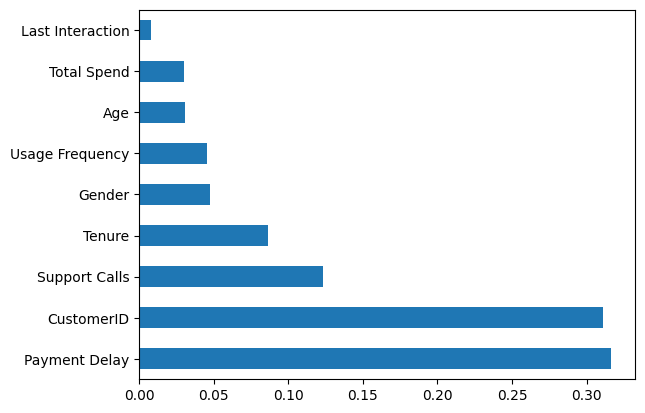

In [12]:
important=pd.Series(
    rf.feature_importances_,
    index=X.columns
)

important.sort_values(ascending=False).head(10).plot.barh()

In [13]:
precision=precision_score(y_test,rf_pred)
recall=recall_score(y_test,rf_pred)
f1=f1_score(y_test,rf_pred)

In [17]:
print("Precision Score: ",precision)
print("Recall Score: ",recall)
print("F1 Score: ",f1)

Precision Score:  0.9932329555066824
Recall Score:  0.9653074646497862
F1 Score:  0.9790711248228133


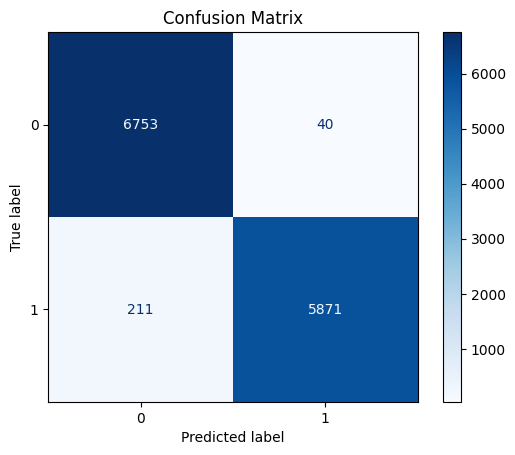

In [16]:
cm=confusion_matrix(y_test,rf_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
